In [23]:
import pandas as pd
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


In [24]:
base_dir = Path("/Users/sofiahorlacher/Downloads/PASSION_MICCAI_2024")
csv = base_dir / "label.csv"
image_folder_path = base_dir / "images"
print("Using label file:", csv)
print("Using image folder:", image_folder_path)
df = pd.read_csv(csv)
df.head()

Using label file: /Users/sofiahorlacher/Downloads/PASSION_MICCAI_2024/label.csv
Using image folder: /Users/sofiahorlacher/Downloads/PASSION_MICCAI_2024/images


,subject_id,country,age,sex,fitzpatrick,body_loc,impetig,conditions_PASSION
0,AA00970008,Madagascar,7,m,3,hair; pelvic; arm; leg,1.0,Eczema
1,AA00970009,Madagascar,3,m,4,back; hair; face; foot; hand; torso; arm; leg,1.0,Eczema
2,AA00970025,Madagascar,3,m,3,torso,0.0,Others
3,AA00970040,Madagascar,7,m,4,arm; foot; hand; torso; leg,1.0,Scabies
4,AA00970047,Madagascar,74,m,3,back; pelvic; arm; hand; torso; leg,0.0,Scabies


## Visualizing Condition Prevalence by Fitzpatrick Skin Type

To better understand how the diagnostic labels are distributed across skin-tone groups in the PASSION dataset, we can visualize the image-level prevalence of each condition by Fitzpatrick skin type. This is particularly relevant for fairness analysis, because the prediction target is `conditions_PASSION`, while Fitzpatrick skin type is used as the sensitive attribute.

We first count how many image files belong to each `subject_id` using the filenames. We then map these counts back to the metadata table so that each subject contributes its total number of images. Finally, we sum the image counts for each combination of condition and Fitzpatrick skin type.

This plot helps reveal whether certain conditions are more represented in some Fitzpatrick groups than in others, which is important when interpreting fairness results.


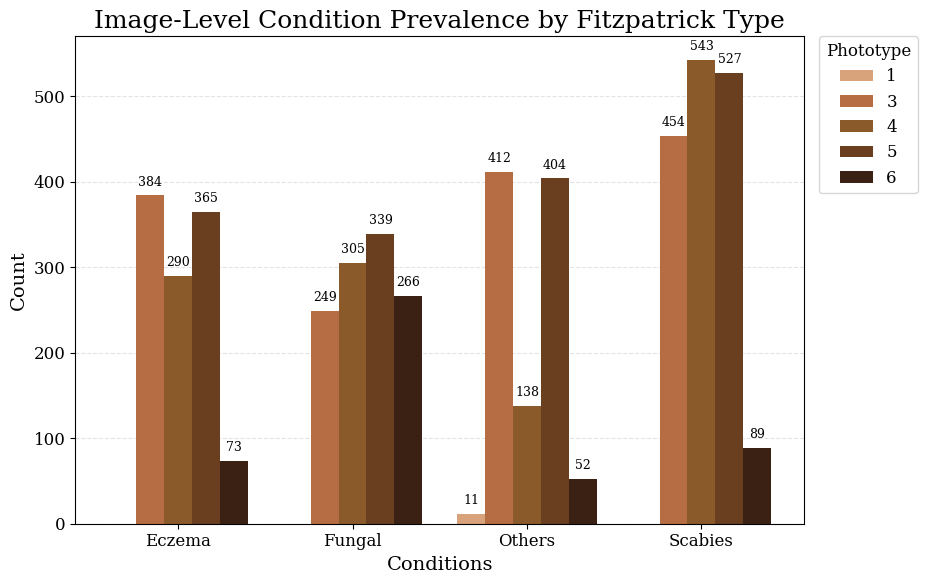

fitzpatrick,1,3,4,5,6
conditions_PASSION,,,,,
Eczema,0,384,290,365,73
Fungal,0,249,305,339,266
Others,11,412,138,404,52
Scabies,0,454,543,527,89


In [25]:
from collections import Counter

image_files = [
    f for f in os.listdir(str(image_folder_path))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
image_subject_counts = Counter(f.split("_")[0] for f in image_files)

plot_df = df.copy()
plot_df["subject_id"] = plot_df["subject_id"].astype(str)
plot_df["fitzpatrick"] = plot_df["fitzpatrick"].astype(str)
plot_df["conditions_PASSION"] = plot_df["conditions_PASSION"].astype(str)
plot_df["image_count"] = plot_df["subject_id"].map(image_subject_counts).fillna(0).astype(int)

# Experimental evaluation subset: Fitzpatrick type 1 is excluded because it only
# contains a single subject and is too sparse for reliable subgroup analysis.
eval_df = df[df["fitzpatrick"].astype(str) != "1"].copy()
plot_df_eval = plot_df[plot_df["fitzpatrick"] != "1"].copy()

# Aggregate to image-level counts: condition x Fitzpatrick
condition_fitz_counts = plot_df.pivot_table(
    index="conditions_PASSION",
    columns="fitzpatrick",
    values="image_count",
    aggfunc="sum",
    fill_value=0,
)

condition_order = ["Eczema", "Fungal", "Others", "Scabies"]
condition_fitz_counts = condition_fitz_counts.reindex(condition_order)
condition_fitz_counts = condition_fitz_counts[
    [c for c in ["1", "3", "4", "5", "6"] if c in condition_fitz_counts.columns]
]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
})

colors = {
    "1": "#d8a27a",
    "3": "#b66d43",
    "4": "#8b5a2b",
    "5": "#6a3f1f",
    "6": "#3b2114",
}

x = np.arange(len(condition_fitz_counts.index))
n_groups = len(condition_fitz_counts.columns)
bar_width = 0.16

plt.figure(figsize=(11, 6))
for i, fitz in enumerate(condition_fitz_counts.columns):
    positions = x + (i - (n_groups - 1) / 2) * bar_width
    values = condition_fitz_counts[fitz].values
    bars = plt.bar(
        positions,
        values,
        width=bar_width,
        label=fitz,
        color=colors.get(fitz, "#8b5a2b"),
    )

    for bar, value in zip(bars, values):
        if value > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value + 8,
                str(int(value)),
                ha="center",
                va="bottom",
                fontsize=9,
            )

plt.title("Image-Level Condition Prevalence by Fitzpatrick Type", fontsize=18)
plt.xlabel("Conditions", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(x, condition_fitz_counts.index)
plt.legend(title="Phototype", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.gca().set_axisbelow(True)

plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()

condition_fitz_counts

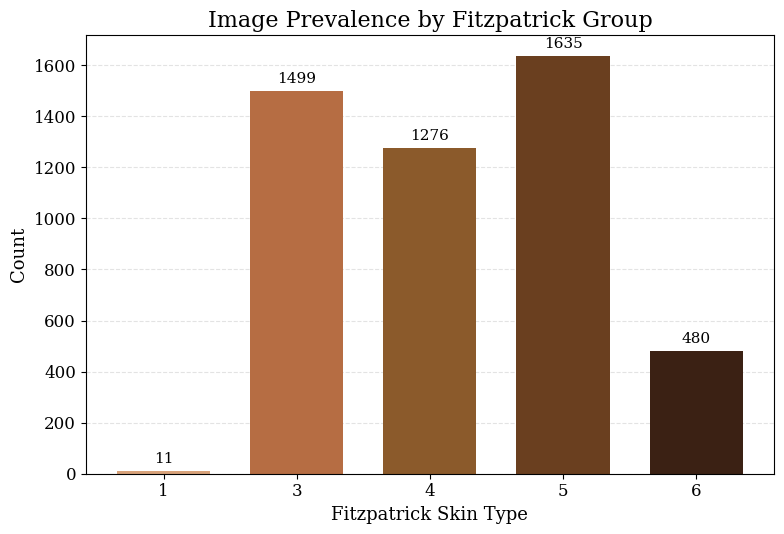

Effective images per Fitzpatrick skin type:
Type 1: 11
Type 3: 1499
Type 4: 1276
Type 5: 1635
Type 6: 480
Total: 4901


In [26]:
from collections import Counter
import os
import matplotlib.pyplot as plt

image_files = [
    f for f in os.listdir(str(image_folder_path))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]
image_subject_counts = Counter(f.split("_")[0] for f in image_files)

subject_to_fitzpatrick = df.set_index("subject_id")["fitzpatrick"].astype(str).to_dict()

fitzpatrick_image_counts = Counter()
for subject_id, n_images in image_subject_counts.items():
    if subject_id in subject_to_fitzpatrick:
        fitzpatrick_image_counts[subject_to_fitzpatrick[subject_id]] += n_images

fitz_types = sorted(fitzpatrick_image_counts.keys(), key=lambda x: int(float(x)))
counts = [fitzpatrick_image_counts[f] for f in fitz_types]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12
})

colors = ["#d8a27a", "#b66d43", "#8b5a2b", "#6a3f1f", "#3b2114"][:len(fitz_types)]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(fitz_types, counts, color=colors, width=0.7, edgecolor="none")

ax.set_title("Image Prevalence by Fitzpatrick Group", fontsize=16)
ax.set_xlabel("Fitzpatrick Skin Type", fontsize=13)
ax.set_ylabel("Count", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

for bar, value in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        str(value),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

print("Effective images per Fitzpatrick skin type:")
for f, c in zip(fitz_types, counts):
    print(f"Type {f}: {c}")
print(f"Total: {sum(counts)}")


## Visualizing Overall Label Distribution

This companion plot shows the overall **image-level distribution of** `conditions_PASSION` across the dataset, without stratifying by Fitzpatrick skin type. It makes the class imbalance easier to inspect directly.


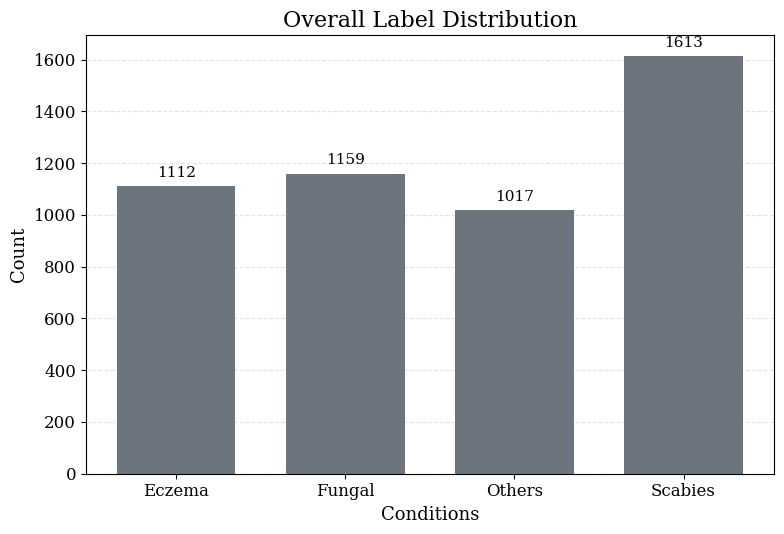

,count
conditions_PASSION,
Eczema,1112
Fungal,1159
Others,1017
Scabies,1613


In [27]:
label_counts = (
    plot_df.groupby("conditions_PASSION")["image_count"]
    .sum()
    .reindex(condition_order)
    .fillna(0)
    .astype(int)
)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
})

label_colors = ["#6C757D"] * len(label_counts)
label_offset = max(label_counts.max() * 0.015, 8)

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(
    label_counts.index,
    label_counts.values,
    color=label_colors,
    width=0.7,
    edgecolor="none",
)

ax.set_title("Overall Label Distribution", fontsize=16)
ax.set_xlabel("Conditions", fontsize=13)
ax.set_ylabel("Count", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

for bar, value in zip(bars, label_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + label_offset,
        str(value),
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

label_counts.to_frame(name="count")


## Recommended Reporting Groups For Fairness Evaluation

The plots above describe the **full PASSION dataset**. For the **subgroup-based experiments and reporting setup**, Fitzpatrick skin type `1` is excluded because it contains only a single subject and does not provide enough support for reliable standalone evaluation.

The experimental reporting setup therefore uses the following grouping logic:

- `fitzpatrick`: exclude skin type `1`; keep `3`, `4`, `5`, and `6` as-is
- `ageGroup`: use `0-4`, `5-17`, `18-39`, `40+`.
- `country`: use `Madagascar`, `Guinea`, `EastAfrica`, where `EastAfrica = Malawi + Tanzania`.
- `sex`: keep as-is.


In [28]:
recommended_fitzpatrick_group = eval_df["fitzpatrick"].astype(str).str.strip()
fitz_support = recommended_fitzpatrick_group.value_counts().rename("count").to_frame()
fitz_support["share"] = (fitz_support["count"] / fitz_support["count"].sum()).round(3)
fitz_condition = pd.crosstab(recommended_fitzpatrick_group, eval_df["conditions_PASSION"])

print("=== Experimental Fitzpatrick groups (type 1 excluded) ===")
display(fitz_support.sort_index(key=lambda idx: idx.astype(int)))
display(fitz_condition.sort_index(key=lambda idx: idx.astype(int)))


=== Experimental Fitzpatrick groups (type 1 excluded) ===


,count,share
fitzpatrick,,
3,354,0.214
4,486,0.294
5,428,0.259
6,384,0.232


conditions_PASSION,Eczema,Fungal,Others,Scabies
fitzpatrick,,,,
3,119,82,57,96
4,121,148,34,183
5,120,117,58,133
6,54,232,39,59


For the experimental subgroup analysis, Fitzpatrick skin type `1` is excluded rather than merged with another group. Although aggregation had initially been considered, it would have changed the subgroup definition in a way that could obscure the interpretation of fairness results.


In [29]:
sex_support = eval_df["sex"].value_counts().rename("count").to_frame()
sex_support["share"] = (sex_support["count"] / sex_support["count"].sum()).round(3)
sex_condition = pd.crosstab(eval_df["sex"], eval_df["conditions_PASSION"])

print("=== Sex support ===")
display(sex_support)
display(sex_condition)


=== Sex support ===


,count,share
sex,,
m,961,0.582
f,691,0.418


conditions_PASSION,Eczema,Fungal,Others,Scabies
sex,,,,
f,191,229,78,193
m,223,350,110,278


Sex is kept unchanged for fairness reporting because both categories have substantial support in the dataset and do not require additional aggregation.


In [30]:
def assign_recommended_age_group(age):
    if pd.isna(age):
        return np.nan
    if age < 5:
        return "0-4"
    if age < 18:
        return "5-17"
    if age < 40:
        return "18-39"
    return "40+"

recommended_age_group = eval_df["age"].apply(assign_recommended_age_group)
age_support = recommended_age_group.value_counts().rename("count").to_frame()
age_support["share"] = (age_support["count"] / age_support["count"].sum()).round(3)
age_condition = pd.crosstab(recommended_age_group, eval_df["conditions_PASSION"])

print("=== Recommended age groups ===")
display(age_support)
display(age_condition)


=== Recommended age groups ===


,count,share
age,,
18-39,594,0.360
5-17,478,0.289
0-4,354,0.214
40+,226,0.137


conditions_PASSION,Eczema,Fungal,Others,Scabies
age,,,,
0-4,129,47,89,89
18-39,134,227,31,202
40+,65,111,6,44
5-17,86,194,62,136


In [31]:
recommended_country_group = eval_df["country"].replace({
    "Malawi": "EastAfrica",
    "Tanzania": "EastAfrica",
})
country_support = recommended_country_group.value_counts().rename("count").to_frame()
country_support["share"] = (country_support["count"] / country_support["count"].sum()).round(3)
country_condition = pd.crosstab(recommended_country_group, eval_df["conditions_PASSION"])

print("=== Recommended country groups ===")
display(country_support)
display(country_condition)


=== Recommended country groups ===


,count,share
country,,
Madagascar,985,0.596
Guinea,384,0.232
EastAfrica,283,0.171


conditions_PASSION,Eczema,Fungal,Others,Scabies
country,,,,
EastAfrica,56,50,120,57
Guinea,57,230,39,58
Madagascar,301,299,29,356
